In [1]:
from common_helper_functions import *

In [2]:
path = "../../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"
rna_hl_human = np.load( path + 'rna_hl_human.npz')

In [3]:
investigate_dataset(rna_hl_human)

['X', 'y', 'genes']

Array shapes:


X shape: (12968, 12288, 6)
y shape: (12968,)
genes shape: (12968,)

First few y values: [ 0.6894531 -0.7753906  0.8334961  1.5537109 -2.1582031]

X dimensions: 3
X first sample shape: (12288, 6)
X first sample, first feature vector: [0. 1. 0. 0. 0.]


In [4]:
pca_embeddings, pca_model = isoform_to_gene_embeddings_pca(rna_hl_human['X'], rna_hl_human['genes'], n_components=1024)
print(f"PCA embeddings shape: {pca_embeddings.shape}")

PCA embeddings shape: (12968, 1024)


In [5]:
total_explained_variance = np.sum(pca_model.explained_variance_ratio_)
print(f"Total explained variance by PCA {total_explained_variance:.2%}")

Total explained variance by PCA 44.54%


In [6]:
pca_embeddings = create_gene_embedding_dataframe(pca_embeddings, rna_hl_human['genes'], method_name="mrl_pca")
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1014,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023
gene_id,,,,,,,,,,,,,,,,,,,,,
M6PR,-8.237841,-1.800441,9.178732,2.385744,2.096814,0.131253,4.832336,-6.338831,2.323424,0.591547,...,0.278232,-0.321846,-0.381568,-0.562626,0.003529,0.050987,0.051660,-0.307516,-1.021125,0.278414
CAMKK1,-2.776547,-2.949902,15.923868,7.525374,2.525743,-0.079425,8.388762,-3.421913,-0.973050,-5.601446,...,0.965462,-0.131112,0.222577,-0.029461,0.527654,0.422687,-1.029793,0.148247,-0.890564,0.298750
RECQL,0.973830,-3.970957,17.951212,9.836151,1.754820,-0.029465,-1.073812,-5.399285,-4.254480,5.011042,...,0.306416,0.446773,-0.288644,-0.462049,1.063396,-0.594798,-0.692057,-0.190557,-0.152062,-1.600763
SLC25A5,-14.954947,-6.669185,-6.679474,-8.113366,-5.334938,6.026591,-3.364492,2.998466,-2.957483,0.411928,...,0.112641,0.517711,0.209691,0.257140,-0.169671,0.035124,0.692156,0.408201,-0.254434,-0.435149
HOXA11,-10.878605,9.096740,-3.441082,-2.067766,3.795659,-5.674852,-4.199434,-0.670058,3.291530,-0.986994,...,-0.134742,-0.123403,0.591845,0.877180,0.296127,-0.759398,-0.306703,-0.690961,0.703981,0.097041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCL4,-15.734598,-0.233562,2.474282,-9.345866,-6.181251,-1.417783,2.460619,3.264150,-5.534049,-0.218972,...,0.429422,-0.143177,-0.039446,0.069536,-0.183573,0.136937,-0.018021,-0.597621,0.335513,-0.360710
TUBGCP5,2.122146,-18.302040,-15.866677,9.272832,4.941909,-1.461290,1.816356,-0.377456,-4.907530,5.436555,...,-0.535597,0.092130,0.582830,0.521000,0.319568,-0.647839,-1.008530,0.327582,-0.453971,-1.145580
UHRF1,3.821117,-17.756678,-14.319549,10.505579,3.448350,2.316565,0.061044,2.354949,-3.479985,-3.825377,...,-0.376417,-1.155195,0.715396,-1.780458,1.058574,-0.403477,-0.514689,0.233016,-0.379249,0.654674


In [7]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [8]:
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1014,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023
gene_id,,,,,,,,,,,,,,,,,,,,,
M6PR,-8.237841,-1.800441,9.178732,2.385744,2.096814,0.131253,4.832336,-6.338831,2.323424,0.591547,...,0.278232,-0.321846,-0.381568,-0.562626,0.003529,0.050987,0.051660,-0.307516,-1.021125,0.278414
CAMKK1,-2.776547,-2.949902,15.923868,7.525374,2.525743,-0.079425,8.388762,-3.421913,-0.973050,-5.601446,...,0.965462,-0.131112,0.222577,-0.029461,0.527654,0.422687,-1.029793,0.148247,-0.890564,0.298750
RECQL,0.973830,-3.970957,17.951212,9.836151,1.754820,-0.029465,-1.073812,-5.399285,-4.254480,5.011042,...,0.306416,0.446773,-0.288644,-0.462049,1.063396,-0.594798,-0.692057,-0.190557,-0.152062,-1.600763
SLC25A5,-14.954947,-6.669185,-6.679474,-8.113366,-5.334938,6.026591,-3.364492,2.998466,-2.957483,0.411928,...,0.112641,0.517711,0.209691,0.257140,-0.169671,0.035124,0.692156,0.408201,-0.254434,-0.435149
HOXA11,-10.878605,9.096740,-3.441082,-2.067766,3.795659,-5.674852,-4.199434,-0.670058,3.291530,-0.986994,...,-0.134742,-0.123403,0.591845,0.877180,0.296127,-0.759398,-0.306703,-0.690961,0.703981,0.097041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCL4,-15.734598,-0.233562,2.474282,-9.345866,-6.181251,-1.417783,2.460619,3.264150,-5.534049,-0.218972,...,0.429422,-0.143177,-0.039446,0.069536,-0.183573,0.136937,-0.018021,-0.597621,0.335513,-0.360710
TUBGCP5,2.122146,-18.302040,-15.866677,9.272832,4.941909,-1.461290,1.816356,-0.377456,-4.907530,5.436555,...,-0.535597,0.092130,0.582830,0.521000,0.319568,-0.647839,-1.008530,0.327582,-0.453971,-1.145580
UHRF1,3.821117,-17.756678,-14.319549,10.505579,3.448350,2.316565,0.061044,2.354949,-3.479985,-3.825377,...,-0.376417,-1.155195,0.715396,-1.780458,1.058574,-0.403477,-0.514689,0.233016,-0.379249,0.654674


In [9]:
NCG_Known_Genes = emogi_predictions[['Name', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = pca_embeddings.merge(NCG_Known_Genes, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
M6PR,-8.237841,-1.800441,9.178732,2.385744,2.096814,0.131253,4.832336,-6.338831,2.323424,0.591547,...,0.003529,0.050987,0.051660,-0.307516,-1.021125,0.278414,False,False,False,False
CAMKK1,-2.776547,-2.949902,15.923868,7.525374,2.525743,-0.079425,8.388762,-3.421913,-0.973050,-5.601446,...,0.527654,0.422687,-1.029793,0.148247,-0.890564,0.298750,False,False,False,False
RECQL,0.973830,-3.970957,17.951212,9.836151,1.754820,-0.029465,-1.073812,-5.399285,-4.254480,5.011042,...,1.063396,-0.594798,-0.692057,-0.190557,-0.152062,-1.600763,False,False,True,False
SLC25A5,-14.954947,-6.669185,-6.679474,-8.113366,-5.334938,6.026591,-3.364492,2.998466,-2.957483,0.411928,...,-0.169671,0.035124,0.692156,0.408201,-0.254434,-0.435149,False,False,False,False
HOXA11,-10.878605,9.096740,-3.441082,-2.067766,3.795659,-5.674852,-4.199434,-0.670058,3.291530,-0.986994,...,0.296127,-0.759398,-0.306703,-0.690961,0.703981,0.097041,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCL4,-15.734598,-0.233562,2.474282,-9.345866,-6.181251,-1.417783,2.460619,3.264150,-5.534049,-0.218972,...,-0.183573,0.136937,-0.018021,-0.597621,0.335513,-0.360710,False,False,False,False
TUBGCP5,2.122146,-18.302040,-15.866677,9.272832,4.941909,-1.461290,1.816356,-0.377456,-4.907530,5.436555,...,0.319568,-0.647839,-1.008530,0.327582,-0.453971,-1.145580,False,False,False,False
UHRF1,3.821117,-17.756678,-14.319549,10.505579,3.448350,2.316565,0.061044,2.354949,-3.479985,-3.825377,...,1.058574,-0.403477,-0.514689,0.233016,-0.379249,0.654674,False,False,False,False


## Predict NCG_Known_Cancer_Gene

In [10]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    9724
True      572
Name: count, dtype: int64

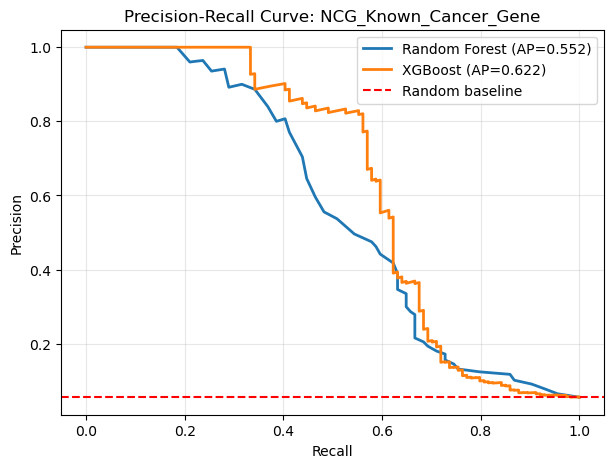

In [11]:
predict_and_plot_pr_curve(merged, 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [12]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    9351
True      945
Name: count, dtype: int64

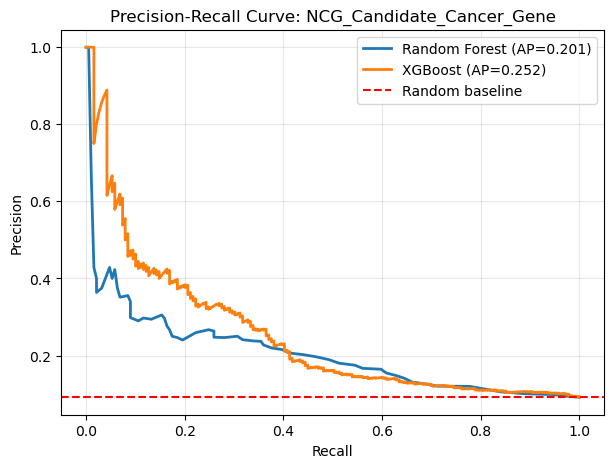

In [13]:
predict_and_plot_pr_curve(merged, 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [14]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    9831
True      465
Name: count, dtype: int64

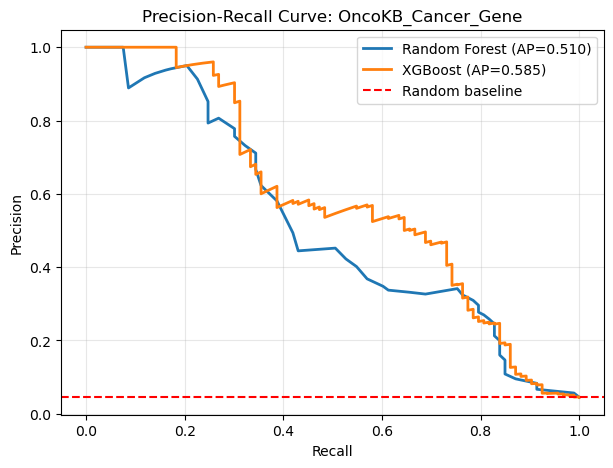

In [15]:
predict_and_plot_pr_curve(merged, 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [16]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    10050
True       246
Name: count, dtype: int64

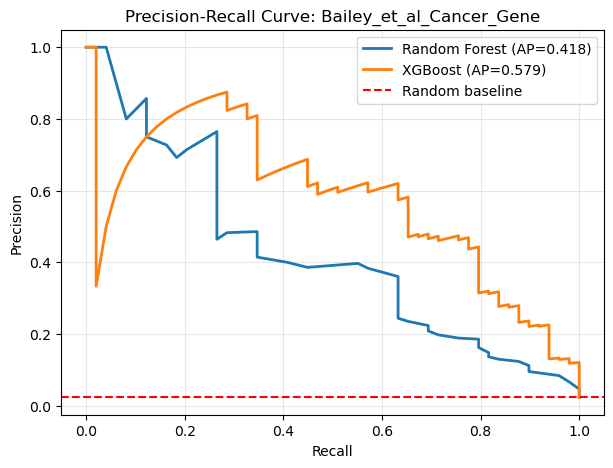

In [17]:
predict_and_plot_pr_curve(merged, 'Bailey_et_al_Cancer_Gene')